<a href="https://colab.research.google.com/github/Parinith-git/codsoft_ds_internship/blob/main/Task5-Credit-Card-Fraud-Detection/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification

# Generate synthetic credit card fraud dataset
X, y = make_classification(n_samples=10000, n_features=10,
                           n_informative=8, weights=[0.97, 0.03],
                           random_state=42)

df = pd.DataFrame(X, columns=[f'V{i}' for i in range(1, 11)])
df['Amount'] = np.abs(np.random.randn(10000)) * 100
df['Class'] = y

print("Shape:", df.shape)
print("\nClass distribution:\n", df['Class'].value_counts())
df.head()

Shape: (10000, 12)

Class distribution:
 Class
0    9649
1     351
Name: count, dtype: int64


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Amount,Class
0,-1.961943,-0.891182,0.454429,-1.611320,1.219083,0.215141,0.691104,1.079864,0.816919,0.252403,75.980862,0
1,-1.390313,-2.245963,1.258776,-2.677441,-1.580437,-2.032223,1.433816,1.817436,0.627775,-4.222150,65.633322,0
2,2.560910,1.289750,1.271519,2.424127,-1.311381,-0.850302,2.476814,0.341372,2.234609,-5.429692,20.402001,0
3,0.255632,-3.290428,1.514160,-0.085143,1.126927,-4.755379,0.820723,2.578251,0.362170,-3.539635,140.988586,0
4,-1.250910,0.373713,1.226333,1.505599,-0.718096,1.228442,2.782940,-1.623311,2.992206,-6.717889,98.068851,0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Features and target
X = df.drop('Class', axis=1)
y = df['Class']

# Handle class imbalance with SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.97      1914
           1       0.96      0.98      0.97      1946

    accuracy                           0.97      3860
   macro avg       0.97      0.97      0.97      3860
weighted avg       0.97      0.97      0.97      3860

Confusion Matrix:
 [[1827   87]
 [  43 1903]]


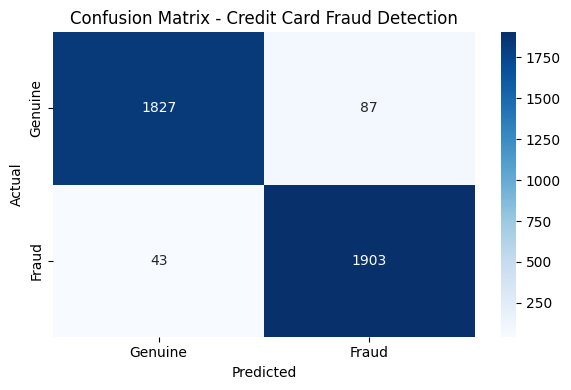

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine', 'Fraud'],
            yticklabels=['Genuine', 'Fraud'])
plt.title('Confusion Matrix - Credit Card Fraud Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()